# Model Selection Summary

This notebook reads the outputs from:

- `experiments/public_ppe_baseline/metrics.json`
- `experiments/yolo8s_ppe/metrics.json`
- `experiments/yolo11s_ppe/metrics.json`

It compares models using dataset metrics, clean FPS, qualitative artifacts, and risk-signal readiness.

**Important:** video inference is only cross-verification/demo realism. The main selection basis is validation metrics + clean runtime on the same sample images.

## 0. Colab / Drive setup

In [1]:
# This cell does NOT copy the project.
# It only locates the existing project folder and uses it as the working directory.
from pathlib import Path
import os
import sys

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")

    # Adjust this only if your project folder has a different name/location on Drive.
    PROJECT_ROOT_CANDIDATES = [
        Path("/content/drive/MyDrive/factory-safety-ai-cctv"),
        Path.cwd(),
    ]
else:
    PROJECT_ROOT_CANDIDATES = [Path.cwd(), *Path.cwd().parents]

def find_project_root(candidates: list[Path]) -> Path:
    for candidate in candidates:
        candidate = candidate.resolve()
        if (candidate / "experiments").exists():
            return candidate
    raise RuntimeError(
        "Could not locate project root. Please open this notebook from the project folder "
        "or update PROJECT_ROOT_CANDIDATES."
    )

PROJECT_ROOT = find_project_root(PROJECT_ROOT_CANDIDATES)
os.chdir(PROJECT_ROOT)

print("Project root:", PROJECT_ROOT)
print("Notebook will read existing files from this folder. No project copy is performed.")

Mounted at /content/drive
Project root: /content/drive/MyDrive/factory-safety-ai-cctv
Notebook will read existing files from this folder. No project copy is performed.


## 1. Imports and helpers

In [2]:
from pathlib import Path
import json
import math
import os
from typing import Any

import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display, Markdown

EXPERIMENTS_DIR = Path("experiments")
MODEL_ORDER = ["public_ppe_baseline", "yolo8s_ppe", "yolo11s_ppe"]

METRIC_FILES = {
    "public_ppe_baseline": EXPERIMENTS_DIR / "public_ppe_baseline" / "metrics.json",
    "yolo8s_ppe": EXPERIMENTS_DIR / "yolo8s_ppe" / "metrics.json",
    "yolo11s_ppe": EXPERIMENTS_DIR / "yolo11s_ppe" / "metrics.json",
}

def read_json(path: Path) -> dict[str, Any]:
    if not path.exists():
        return {
            "status": "missing",
            "errors": {"read_error": f"Missing file: {path}"},
            "dataset_metrics": {},
            "runtime_metrics": {},
            "risk_signal_readiness": {},
        }
    try:
        return json.loads(path.read_text(encoding="utf-8"))
    except Exception as exc:
        return {
            "status": "invalid_json",
            "errors": {"read_error": str(exc)},
            "dataset_metrics": {},
            "runtime_metrics": {},
            "risk_signal_readiness": {},
        }

def get_nested(data: dict, *keys: str, default: Any = "TBD") -> Any:
    current = data
    for key in keys:
        if not isinstance(current, dict) or key not in current:
            return default
        current = current[key]
    return current

def to_float_or_none(value: Any) -> float | None:
    if value is None:
        return None
    if isinstance(value, (int, float)):
        if math.isnan(value):
            return None
        return float(value)
    if isinstance(value, str):
        if value.strip().upper() in {"TBD", "N/A", "NA", "NONE", "NULL", ""}:
            return None
        try:
            return float(value)
        except ValueError:
            return None
    return None

def fmt(value: Any, digits: int = 4) -> str:
    f = to_float_or_none(value)
    if f is None:
        return str(value)
    return f"{f:.{digits}f}"

def safe_md(value: Any) -> str:
    if value is None:
        return "null"
    text = str(value).replace("\n", " ").replace("|", "\\|")
    return text

CHARTS_DIR = EXPERIMENTS_DIR / "model_selection_charts"
CHARTS_DIR.mkdir(parents=True, exist_ok=True)

def format_bar_value(value: Any, digits: int = 3, integer: bool = False) -> str:
    f = to_float_or_none(value)
    if f is None:
        return ""
    if integer:
        return f"{f:.0f}"
    if abs(f) >= 100:
        return f"{f:.1f}"
    if abs(f) >= 10:
        return f"{f:.2f}"
    return f"{f:.{digits}f}"

def add_bar_labels(ax, digits: int = 3, integer: bool = False, rotation: int = 0, fontsize: int = 8) -> None:
    """Add readable numeric labels on top of all bars in a matplotlib bar chart."""
    for container in ax.containers:
        labels = [format_bar_value(bar.get_height(), digits=digits, integer=integer) for bar in container]
        ax.bar_label(container, labels=labels, padding=3, fontsize=fontsize, rotation=rotation)

def save_chart(filename: str) -> None:
    output_path = CHARTS_DIR / filename
    plt.savefig(output_path, dpi=200, bbox_inches="tight")
    print(f"Saved chart: {output_path}")


## 2. Load available metrics

In [3]:
metrics_by_model = {model_id: read_json(path) for model_id, path in METRIC_FILES.items()}

print("Metrics files:")
for model_id, path in METRIC_FILES.items():
    print(f"- {model_id}: {path} | exists={path.exists()}")

metrics_by_model

Metrics files:
- public_ppe_baseline: experiments/public_ppe_baseline/metrics.json | exists=True
- yolo8s_ppe: experiments/yolo8s_ppe/metrics.json | exists=True
- yolo11s_ppe: experiments/yolo11s_ppe/metrics.json | exists=True


{'public_ppe_baseline': {'model_id': 'public_ppe_baseline',
  'base_model': 'hf://Hexmon/vyra-yolo-ppe-detection/best.pt',
  'local_model_path': '/root/.cache/huggingface/hub/models--Hexmon--vyra-yolo-ppe-detection/snapshots/08895b33d95d2587423ebe4f7c1b9c41beebd642/best.pt',
  'role': 'external_baseline',
  'dataset_yaml': 'experiments/runtime_dataset_yaml/roboflow_hard_hat_workers_yolov11_runtime.yaml',
  'status': 'qualitative_inference_completed',
  'errors': {'model_load_error': None},
  'class_names': {'0': 'Fall-Detected',
   '1': 'Gloves',
   '2': 'Goggles',
   '3': 'Hardhat',
   '4': 'Ladder',
   '5': 'Mask',
   '6': 'NO-Gloves',
   '7': 'NO-Goggles',
   '8': 'NO-Hardhat',
   '9': 'NO-Mask',
   '10': 'NO-Safety Vest',
   '11': 'Person',
   '12': 'Safety Cone',
   '13': 'Safety Vest'},
  'class_mapping': {'Person': 'person',
   'Hardhat': 'helmet',
   'NO-Hardhat': 'head'},
  'mapped_classes': ['Hardhat', 'NO-Hardhat', 'Person'],
  'ignored_classes': ['Fall-Detected',
   'Gloves

## 3. Build comparison table

In [4]:
rows = []

for model_id in MODEL_ORDER:
    metrics = metrics_by_model.get(model_id, {})
    dataset_metrics = metrics.get("dataset_metrics", {}) or {}
    runtime_metrics = metrics.get("runtime_metrics", {}) or {}

    is_public = model_id == "public_ppe_baseline"
    qualitative_only = bool(metrics.get("qualitative_only", is_public))

    rows.append({
        "model_id": model_id,
        "base_model": metrics.get("base_model", "TBD"),
        "role": metrics.get("role", "TBD"),
        "status": metrics.get("status", "TBD"),
        "quantitative_eval": not qualitative_only and to_float_or_none(dataset_metrics.get("mAP50")) is not None,
        "dataset_yaml": metrics.get("dataset_yaml", "TBD"),
        "mAP50": dataset_metrics.get("mAP50", "N/A" if is_public else "TBD"),
        "mAP50_95": dataset_metrics.get("mAP50_95", "N/A" if is_public else "TBD"),
        "precision": dataset_metrics.get("precision", "N/A" if is_public else "TBD"),
        "recall": dataset_metrics.get("recall", "N/A" if is_public else "TBD"),
        "avg_ms": runtime_metrics.get("avg_inference_ms_per_image", "TBD"),
        "fps": runtime_metrics.get("fps_estimate", "TBD"),
        "benchmark_type": runtime_metrics.get("benchmark_type", "TBD"),
        "sample_prediction_dir": get_nested(metrics, "qualitative_outputs", "sample_prediction_dir", default="TBD"),
        "video_prediction_dir": get_nested(metrics, "qualitative_outputs", "video_prediction_dir", default="TBD"),
        "risk_notes": get_nested(metrics, "risk_signal_readiness", "notes", default="TBD"),
    })

comparison_df = pd.DataFrame(rows)
display(comparison_df)

,model_id,base_model,role,status,quantitative_eval,dataset_yaml,mAP50,mAP50_95,precision,recall,avg_ms,fps,benchmark_type,sample_prediction_dir,video_prediction_dir,risk_notes
0,public_ppe_baseline,hf://Hexmon/vyra-yolo-ppe-detection/best.pt,external_baseline,qualitative_inference_completed,False,experiments/runtime_dataset_yaml/roboflow_hard...,N/A,N/A,N/A,N/A,28.736600,34.798828,clean_predict_no_save_after_warmup,experiments/public_ppe_baseline/runs/predict_s...,TBD,Person -> person_detected; Hardhat -> helmet_d...
1,yolo8s_ppe,yolov8s.pt,baseline,sample_prediction_completed,True,/content/factory-safety-ai-cctv/data/processed...,0.654013,0.444279,0.962179,0.613134,14.122313,70.809932,clean_predict_no_save_after_warmup,/content/factory-safety-ai-cctv/experiments/yo...,TBD,Raw YOLO boxes/classes/confidences can feed pe...
2,yolo11s_ppe,yolo11s.pt,primary_candidate,sample_prediction_completed,True,data/processed/ppe_yolo/data.yaml,0.65045,0.438751,0.96174,0.611562,15.017337,66.589705,clean_predict_no_save_after_warmup,/content/factory-safety-ai-cctv/experiments/yo...,TBD,Raw YOLO boxes/classes/confidences can feed pe...


## 4. Metric charts

Saved chart: experiments/model_selection_charts/selected_model_overall_comparison.png


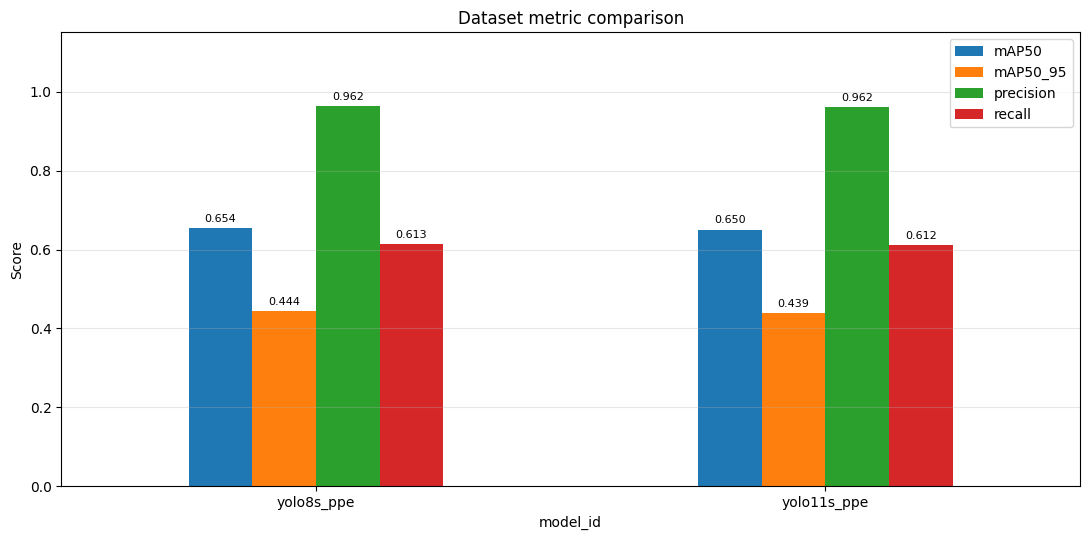

Saved chart: experiments/model_selection_charts/report_chart_fps_comparison.png


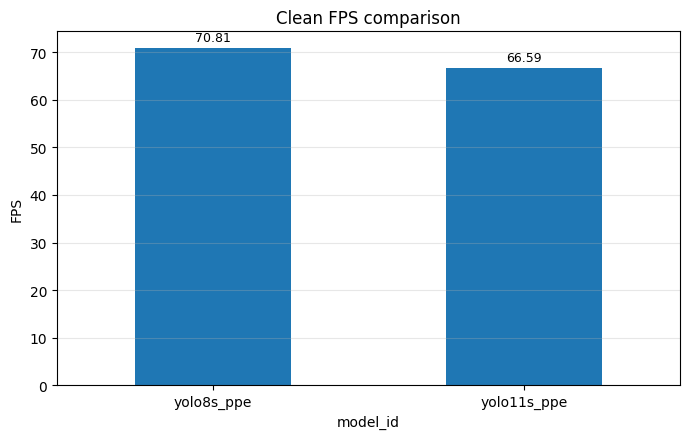

Saved chart: experiments/model_selection_charts/report_chart_avg_ms_comparison.png


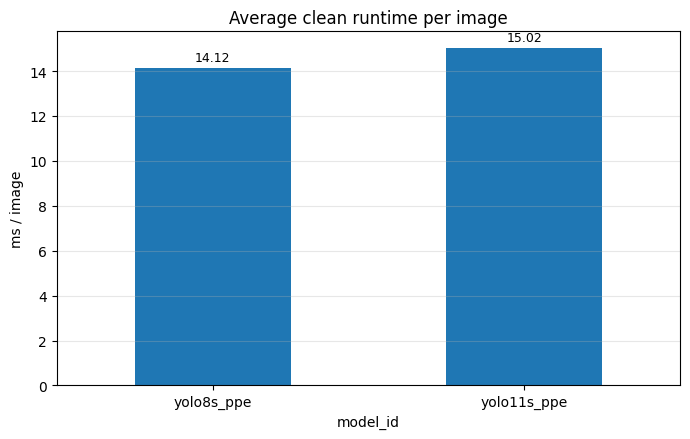

In [5]:
# Dataset metrics: only trained candidates with compatible quantitative evaluation.
metric_cols = ["mAP50", "mAP50_95", "precision", "recall"]
plot_df = comparison_df[comparison_df["quantitative_eval"]].copy()

for col in metric_cols + ["fps", "avg_ms"]:
    plot_df[col] = plot_df[col].apply(to_float_or_none)

if plot_df.empty:
    print("No quantitative model metrics available yet.")
else:
    ax = plot_df.set_index("model_id")[metric_cols].plot(kind="bar", figsize=(11, 5.5))
    ax.set_title("Dataset metric comparison")
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1.15)
    ax.grid(axis="y", alpha=0.3)
    add_bar_labels(ax, digits=3, fontsize=8)
    plt.xticks(rotation=0)
    plt.tight_layout()
    save_chart("selected_model_overall_comparison.png")
    plt.show()

    ax = plot_df.set_index("model_id")["fps"].plot(kind="bar", figsize=(7, 4.5))
    ax.set_title("Clean FPS comparison")
    ax.set_ylabel("FPS")
    ax.grid(axis="y", alpha=0.3)
    add_bar_labels(ax, digits=2, fontsize=9)
    plt.xticks(rotation=0)
    plt.tight_layout()
    save_chart("report_chart_fps_comparison.png")
    plt.show()

    ax = plot_df.set_index("model_id")["avg_ms"].plot(kind="bar", figsize=(7, 4.5))
    ax.set_title("Average clean runtime per image")
    ax.set_ylabel("ms / image")
    ax.grid(axis="y", alpha=0.3)
    add_bar_labels(ax, digits=2, fontsize=9)
    plt.xticks(rotation=0)
    plt.tight_layout()
    save_chart("report_chart_avg_ms_comparison.png")
    plt.show()


## 5. Qualitative output availability

In [6]:
artifact_rows = []

for model_id in MODEL_ORDER:
    exp_dir = EXPERIMENTS_DIR / model_id
    pred_dir_candidates = [
        exp_dir / "runs" / "predict_samples",
        Path(str(comparison_df.loc[comparison_df["model_id"] == model_id, "sample_prediction_dir"].iloc[0])) if not comparison_df.loc[comparison_df["model_id"] == model_id].empty else Path(""),
    ]

    pred_dir = None
    image_count = 0
    for candidate in pred_dir_candidates:
        if candidate.exists():
            pred_dir = candidate
            image_count = len(list(candidate.rglob("*.jpg"))) + len(list(candidate.rglob("*.png"))) + len(list(candidate.rglob("*.jpeg")))
            break

    risk_preview = exp_dir / "risk_signal_preview.csv"
    det_summary = exp_dir / "sample_detection_summary.csv"
    metrics_path = exp_dir / "metrics.json"

    artifact_rows.append({
        "model_id": model_id,
        "metrics_json": metrics_path.exists(),
        "predict_samples_dir": str(pred_dir) if pred_dir else "missing",
        "predict_image_count": image_count,
        "detection_summary_csv": det_summary.exists(),
        "risk_signal_preview_csv": risk_preview.exists(),
    })

artifact_df = pd.DataFrame(artifact_rows)
display(artifact_df)

,model_id,metrics_json,predict_samples_dir,predict_image_count,detection_summary_csv,risk_signal_preview_csv
0,public_ppe_baseline,True,experiments/public_ppe_baseline/runs/predict_s...,12,False,False
1,yolo8s_ppe,True,experiments/yolo8s_ppe/runs/predict_samples,12,True,True
2,yolo11s_ppe,True,experiments/yolo11s_ppe/runs/predict_samples,12,True,True


## 6. Visualize annotated sample predictions

Annotated predictions: public_ppe_baseline


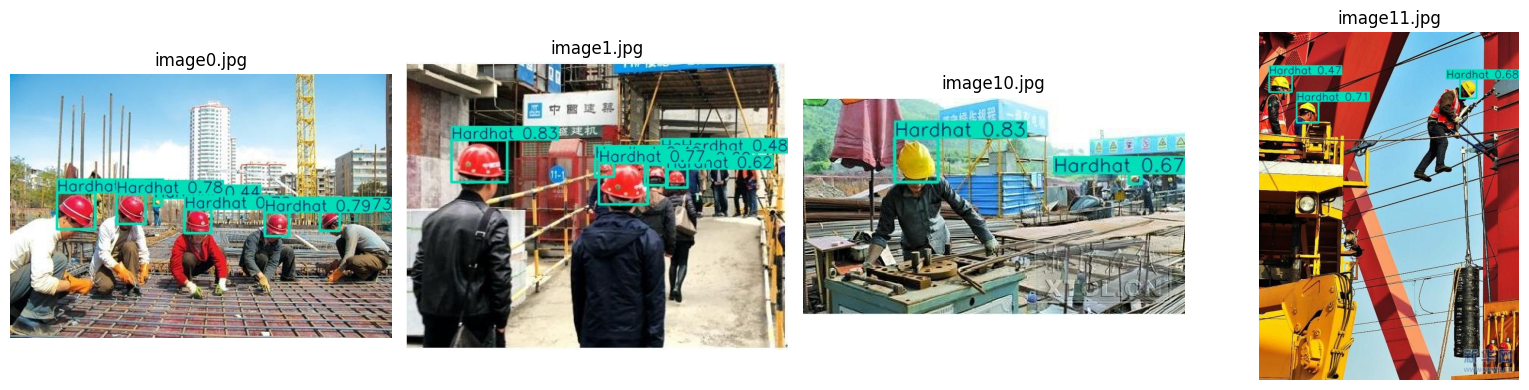

Annotated predictions: yolo8s_ppe


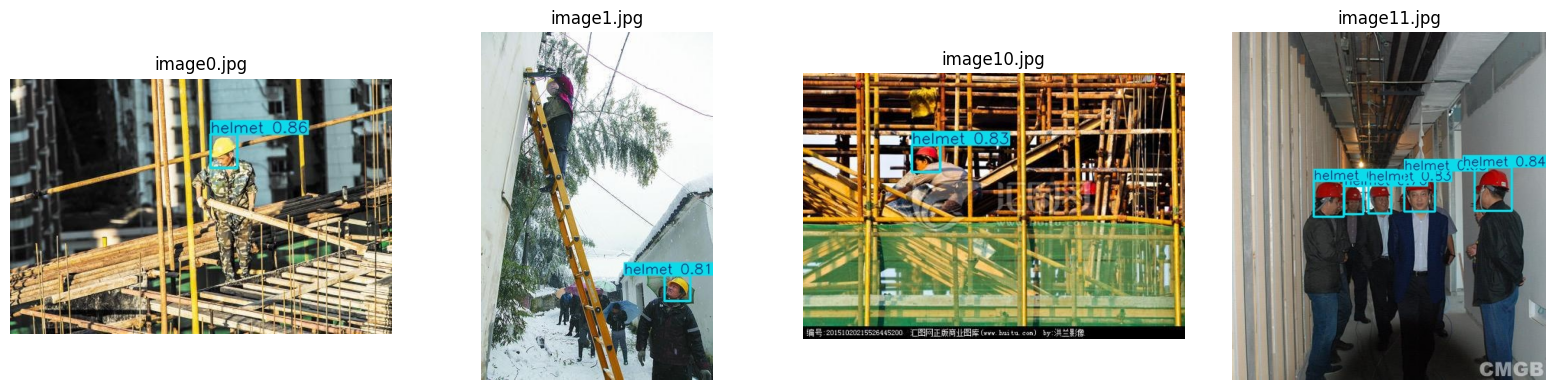

Annotated predictions: yolo11s_ppe


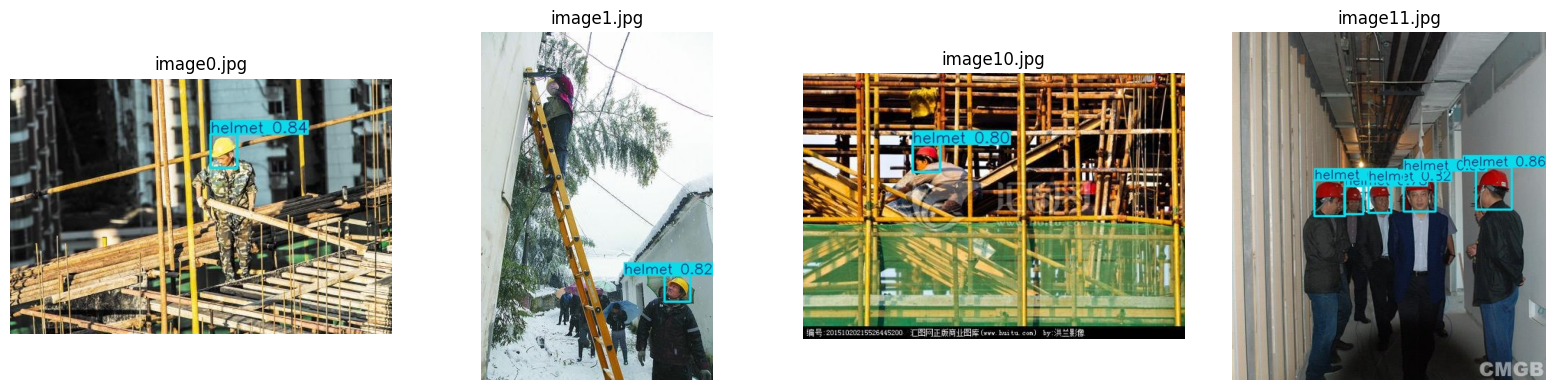

In [7]:
def collect_prediction_images(model_id: str, limit: int = 4) -> list[Path]:
    exp_dir = EXPERIMENTS_DIR / model_id
    candidates = [
        exp_dir / "runs" / "predict_samples",
        Path(str(comparison_df.loc[comparison_df["model_id"] == model_id, "sample_prediction_dir"].iloc[0])) if not comparison_df.loc[comparison_df["model_id"] == model_id].empty else Path(""),
    ]
    images = []
    for candidate in candidates:
        if candidate.exists():
            images = sorted([p for p in candidate.rglob("*") if p.suffix.lower() in {".jpg", ".jpeg", ".png"}])
            if images:
                break
    return images[:limit]

for model_id in MODEL_ORDER:
    images = collect_prediction_images(model_id, limit=4)
    if not images:
        print(f"No annotated predictions found for {model_id}")
        continue

    print(f"Annotated predictions: {model_id}")
    fig, axes = plt.subplots(1, len(images), figsize=(4 * len(images), 4))
    if len(images) == 1:
        axes = [axes]

    for ax, img_path in zip(axes, images):
        img = Image.open(img_path).convert("RGB")
        ax.imshow(img)
        ax.set_title(img_path.name)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

## 7. Risk-signal preview comparison

,model_id,sample_count,person_detected_images,helmet_detected_images,head_or_no_helmet_detected_images,note
0,public_ppe_baseline,0,missing,missing,missing,risk_signal_preview.csv missing
1,yolo8s_ppe,12,0,10,2,"sample-level risk signal bridge, not final ris..."
2,yolo11s_ppe,12,0,10,2,"sample-level risk signal bridge, not final ris..."


Saved chart: experiments/model_selection_charts/risk_signal_readiness_comparison.png


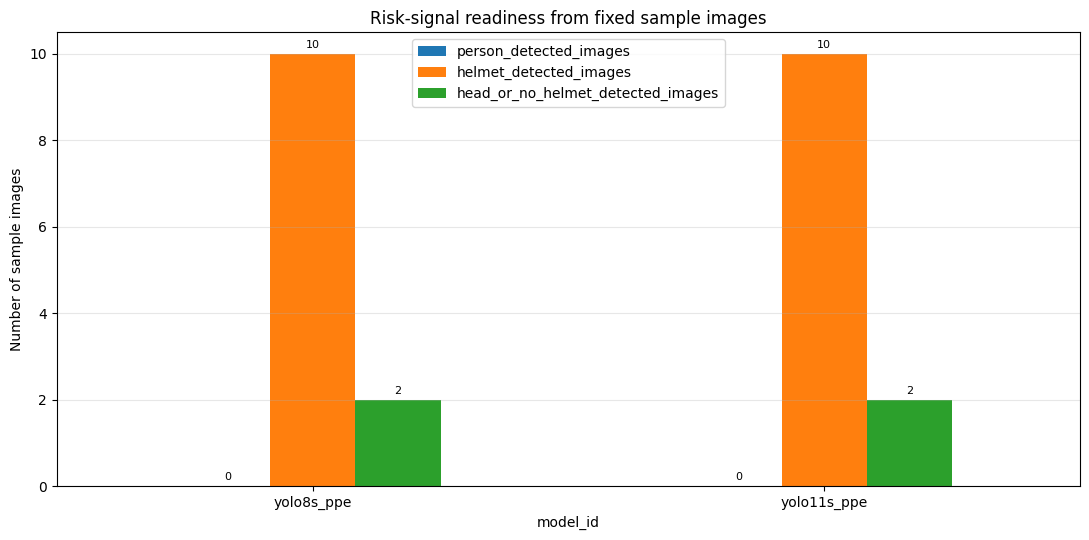

In [8]:
risk_rows = []

for model_id in MODEL_ORDER:
    risk_path = EXPERIMENTS_DIR / model_id / "risk_signal_preview.csv"
    if not risk_path.exists():
        risk_rows.append({
            "model_id": model_id,
            "sample_count": 0,
            "person_detected_images": "missing",
            "helmet_detected_images": "missing",
            "head_or_no_helmet_detected_images": "missing",
            "note": "risk_signal_preview.csv missing",
        })
        continue

    df = pd.read_csv(risk_path)
    row = {
        "model_id": model_id,
        "sample_count": len(df),
        "person_detected_images": int(df.get("person_detected", pd.Series(dtype=bool)).fillna(False).astype(bool).sum()) if "person_detected" in df else "TBD",
        "helmet_detected_images": int(df.get("helmet_detected", pd.Series(dtype=bool)).fillna(False).astype(bool).sum()) if "helmet_detected" in df else "TBD",
        "head_or_no_helmet_detected_images": int(df.get("head_or_no_helmet_detected", pd.Series(dtype=bool)).fillna(False).astype(bool).sum()) if "head_or_no_helmet_detected" in df else "TBD",
        "note": "sample-level risk signal bridge, not final risk scoring",
    }
    risk_rows.append(row)

risk_df = pd.DataFrame(risk_rows)
display(risk_df)

plot_risk_df = risk_df.copy()
for col in ["person_detected_images", "helmet_detected_images", "head_or_no_helmet_detected_images"]:
    plot_risk_df[col] = plot_risk_df[col].apply(to_float_or_none)

valid_risk_df = plot_risk_df.dropna(subset=["person_detected_images", "helmet_detected_images", "head_or_no_helmet_detected_images"], how="all")

if valid_risk_df.empty:
    print("No risk-signal preview data available for plotting.")
else:
    ax = valid_risk_df.set_index("model_id")[[
        "person_detected_images",
        "helmet_detected_images",
        "head_or_no_helmet_detected_images",
    ]].plot(kind="bar", figsize=(11, 5.5))
    ax.set_title("Risk-signal readiness from fixed sample images")
    ax.set_ylabel("Number of sample images")
    ax.grid(axis="y", alpha=0.3)
    add_bar_labels(ax, integer=True, fontsize=8)
    plt.xticks(rotation=0)
    plt.tight_layout()
    save_chart("risk_signal_readiness_comparison.png")
    plt.show()


## 8. Selection heuristic

,model_id,recall,mAP50,mAP50_95,fps,fps_norm,safety_oriented_score
0,yolo8s_ppe,0.613134,0.654013,0.444279,70.809932,1.000000,0.656055
1,yolo11s_ppe,0.611562,0.650450,0.438751,66.589705,0.940401,0.644688


**Provisional recommendation:** `yolo8s_ppe` has the highest safety-oriented score among trained candidates.

This recommendation is provisional because Phase 2 is still a smoke experiment.
Score gap vs next candidate: `0.0114`.
The gap is small, so treat the result as a tie unless qualitative/video checks strongly favor one model.

⚠️ **Important safety warning:** fixed sample risk previews show no `person_detected` images for trained candidates.
Camera 1 and Camera 2 require person detection for danger-zone intrusion. Before final deployment, improve label alignment, person data coverage, and training duration.

Saved chart: experiments/model_selection_charts/safety_oriented_selection_score.png


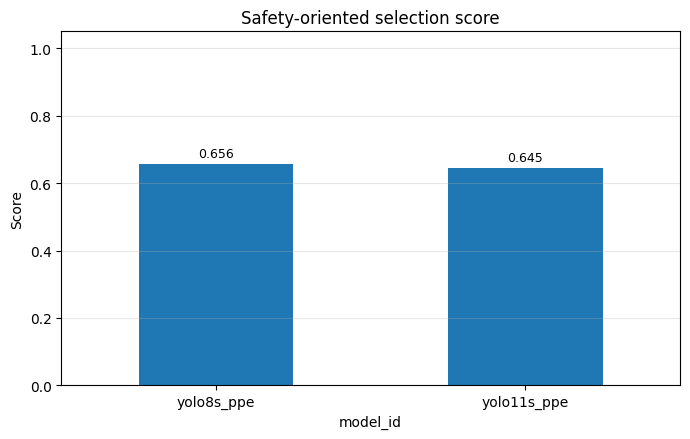

In [9]:
# Safety-oriented heuristic for trained candidates only.
# This is not a benchmark metric. It only helps summarize the next direction.
# Recall is weighted highest because missing a violation is riskier than a false warning.

selection_rows = []

candidate_df = comparison_df[comparison_df["quantitative_eval"]].copy()
for col in ["mAP50", "mAP50_95", "precision", "recall", "fps"]:
    candidate_df[col] = candidate_df[col].apply(to_float_or_none)

if candidate_df.empty:
    display(Markdown("**Recommendation:** TBD. Run YOLOv8s and YOLOv11s notebooks first."))
else:
    max_fps = candidate_df["fps"].max()
    for _, row in candidate_df.iterrows():
        fps_norm = (row["fps"] / max_fps) if max_fps and not math.isnan(max_fps) else 0
        safety_score = (
            0.45 * (row["recall"] or 0)
            + 0.25 * (row["mAP50"] or 0)
            + 0.15 * (row["mAP50_95"] or 0)
            + 0.15 * fps_norm
        )
        selection_rows.append({
            "model_id": row["model_id"],
            "recall": row["recall"],
            "mAP50": row["mAP50"],
            "mAP50_95": row["mAP50_95"],
            "fps": row["fps"],
            "fps_norm": fps_norm,
            "safety_oriented_score": safety_score,
        })

    selection_df = pd.DataFrame(selection_rows).sort_values("safety_oriented_score", ascending=False)
    display(selection_df)

    best = selection_df.iloc[0]
    second = selection_df.iloc[1] if len(selection_df) > 1 else None

    recommendation_lines = [
        f"**Provisional recommendation:** `{best['model_id']}` has the highest safety-oriented score among trained candidates.",
        "",
        "This recommendation is provisional because Phase 2 is still a smoke experiment.",
    ]

    if second is not None:
        delta = best["safety_oriented_score"] - second["safety_oriented_score"]
        recommendation_lines.append(f"Score gap vs next candidate: `{delta:.4f}`.")
        if abs(delta) < 0.03:
            recommendation_lines.append("The gap is small, so treat the result as a tie unless qualitative/video checks strongly favor one model.")

    # Person detection warning from risk preview.
    if "risk_df" in globals():
        trained_risk = risk_df[risk_df["model_id"].isin(candidate_df["model_id"].tolist())]
        if not trained_risk.empty:
            person_counts = []
            for value in trained_risk["person_detected_images"].tolist():
                f = to_float_or_none(value)
                if f is not None:
                    person_counts.append(f)
            if person_counts and max(person_counts) == 0:
                recommendation_lines.extend([
                    "",
                    "⚠️ **Important safety warning:** fixed sample risk previews show no `person_detected` images for trained candidates.",
                    "Camera 1 and Camera 2 require person detection for danger-zone intrusion. Before final deployment, improve label alignment, person data coverage, and training duration.",
                ])

    display(Markdown("\n".join(recommendation_lines)))

    ax = selection_df.set_index("model_id")["safety_oriented_score"].plot(kind="bar", figsize=(7, 4.5))
    ax.set_title("Safety-oriented selection score")
    ax.set_ylabel("Score")
    ax.set_ylim(0, max(1.05, float(selection_df["safety_oriented_score"].max()) * 1.15))
    ax.grid(axis="y", alpha=0.3)
    add_bar_labels(ax, digits=3, fontsize=9)
    plt.xticks(rotation=0)
    plt.tight_layout()
    save_chart("safety_oriented_selection_score.png")
    plt.show()


## 9. Write summary files

In [10]:
def table_to_markdown(df: pd.DataFrame) -> str:
    return df.to_markdown(index=False)

summary_path = EXPERIMENTS_DIR / "model_selection_summary.md"
benchmark_path = EXPERIMENTS_DIR / "benchmark_summary.md"

# Build recommendation text.
recommended_text = "TBD"
if "selection_df" in globals() and not selection_df.empty:
    best = selection_df.iloc[0]
    recommended_text = f"Provisional: {best['model_id']} based on the safety-oriented heuristic. Treat as provisional until longer training, label alignment, and video cross-check are completed."

summary_lines = [
    "# Model Selection Summary",
    "",
    f"Recommendation: **{recommended_text}**",
    "",
    "## Comparison Table",
    "",
    table_to_markdown(comparison_df),
    "",
    "## Risk-Signal Preview",
    "",
    table_to_markdown(risk_df) if "risk_df" in globals() else "Risk preview not available.",
    "",
    "## Selection Rule",
    "",
    "- Prefer the model with better recall for safety-critical classes if speed is acceptable.",
    "- Helmet/no-helmet recall is more important than slightly higher precision because missing a violation is more dangerous than a false warning.",
    "- Public PPE baseline is qualitative/external unless label mapping and evaluation are aligned.",
    "- Video inference is cross-verification/demo realism, not the primary quantitative benchmark.",
    "",
    "## Important Limitation",
    "",
    "The current smoke experiments use the Roboflow fallback YAML. Its class order is `['head', 'helmet', 'person']`, while the final project schema is `['person', 'helmet', 'head']`. Final training should remap labels before risk scoring integration.",
    "",
    "## Next Direction",
    "",
    "1. Use the best smoke candidate as the next training candidate.",
    "2. Remap YOLO labels to the project schema.",
    "3. Improve person detection for Camera 1 and Camera 2.",
    "4. Run longer training and then perform video cross-verification.",
]

summary_path.parent.mkdir(parents=True, exist_ok=True)
summary_path.write_text("\n".join(summary_lines), encoding="utf-8")
print(f"Wrote {summary_path}")

benchmark_rows = []
for _, row in comparison_df.iterrows():
    is_public = row["model_id"] == "public_ppe_baseline"
    benchmark_rows.append({
        "model_id": row["model_id"],
        "base_model": row["base_model"],
        "role": row["role"],
        "dataset": row["dataset_yaml"],
        "train_status": "not trained" if is_public else row["status"],
        "val_status": "qualitative only" if is_public else row["status"],
        "mAP50": row["mAP50"],
        "mAP50-95": row["mAP50_95"],
        "precision": row["precision"],
        "recall": row["recall"],
        "FPS": row["fps"],
        "notes": "label space differs; qualitative baseline" if is_public else "smoke training result",
    })

benchmark_df = pd.DataFrame(benchmark_rows)
benchmark_lines = [
    "# Benchmark Summary",
    "",
    "This file is generated from available metrics JSON files. Do not invent numbers.",
    "",
    table_to_markdown(benchmark_df),
]
benchmark_path.write_text("\n".join(benchmark_lines), encoding="utf-8")
print(f"Wrote {benchmark_path}")

Wrote experiments/model_selection_summary.md
Wrote experiments/benchmark_summary.md


## 10. Sync summary results back to Google Drive

In [11]:
# No separate Google Drive sync is needed.
# The notebook reads and writes directly inside PROJECT_ROOT / experiments.
print("No project copy or Drive sync is performed by this notebook.")
print(f"Outputs are written to: {EXPERIMENTS_DIR.resolve()}")

No project copy or Drive sync is performed by this notebook.
Outputs are written to: /content/drive/MyDrive/factory-safety-ai-cctv/experiments
